# 3D toric code — phase diagram in the $(h_z, h_x)$ plane

Hand-plotted phase boundary from the NQS transition estimates. Axes: $h_z$
(horizontal), $h_x$ (vertical). Two cuts: the **vertical** $h_z$ transition
(~0.21) and the **horizontal** $h_x$ transition (~1.0). The **topological** phase
is the bottom-left corner — small in *both* fields; everywhere past either line is
**trivial**. Enter each boundary's points (with error bars) in §1 and run §2.

In [8]:
# ====================== 1 · INPUT — edit these ======================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe

# VERTICAL boundary — the h_z transition (near h_z=0.21).
#   rows: (hx, hz_c, hz_c_err)   error bar on hz_c -> HORIZONTAL (h_z is the x-axis)
BOUNDARY_V = [
    (0.0, 0.216,   0.04),
    (0.2, 0.2307,  0.03),
    (0.4, 0.2198,  0.04),
    (0.6, 0.21185, 0.03),
]

# HORIZONTAL boundary — the h_x transition (near h_x=1.0).
#   rows: (hz, hx_c, hx_c_err)   error bar on hx_c -> VERTICAL (h_x is the y-axis)
#   placeholder until the h_x-transition experiments finish; set to [] to hide.
BOUNDARY_H = [
    (0.0,  0.92, 0.10),
]

# ---- plot window & style knobs ----
HZ_LIM = (0.0, 0.5)       # x-axis (h_z) range
HX_LIM = (0.0, 2.0)       # y-axis (h_x) range
C_TOPO = "#2a78d6"        # topological (small BOTH fields) — cool blue
C_TRIV = "#e34948"        # trivial (large EITHER field)    — warm red
C_LINE = "#12213a"        # phase-boundary line + markers   — dark ink
print(f"vertical: {len(BOUNDARY_V)} pts | horizontal: {len(BOUNDARY_H)} pts")

vertical: 4 pts | horizontal: 1 pts


## 2 · Phase diagram

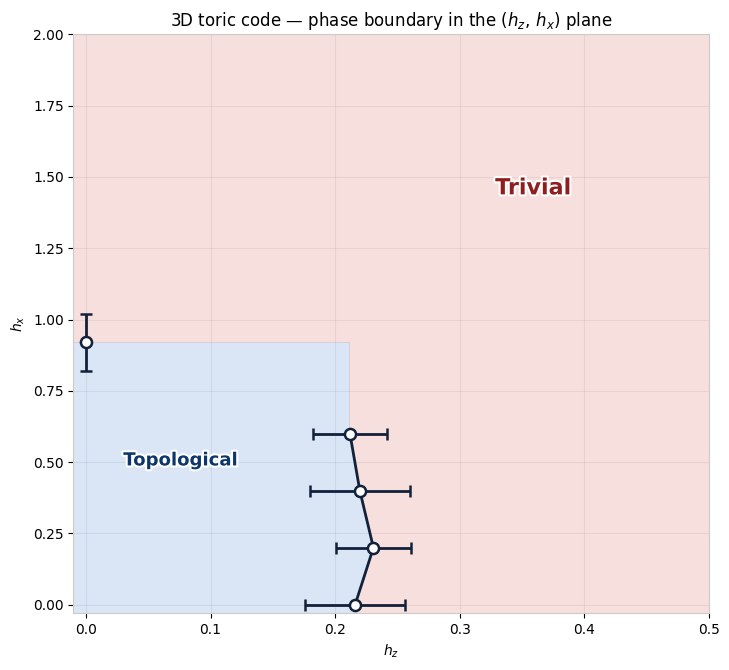

In [9]:
# ====================== 2 · PLOT ======================
def _interp(x, pts, ix, iy):
    """y(x) from boundary points, sorted by column ix, clamped flat outside range."""
    q = sorted(pts, key=lambda r: r[ix])
    return np.interp(np.ravel(x), [r[ix] for r in q], [r[iy] for r in q]).reshape(np.shape(x))

PAD_X = 0.03
PAD_Y = 0.01                                   # margin so edge points/bars aren't clipped
xlo, xhi = HZ_LIM[0] - PAD_Y, HZ_LIM[1]
ylo, yhi = HX_LIM[0] - PAD_X, HX_LIM[1]

# topological = small in BOTH fields:  hz < hz_c(hx)  AND  hx < hx_c(hz)
zz = np.linspace(xlo, xhi, 600); xx = np.linspace(ylo, yhi, 600)
ZZ, XX = np.meshgrid(zz, xx)
topo = np.ones_like(ZZ, dtype=bool)
if BOUNDARY_V: topo &= ZZ < _interp(XX, BOUNDARY_V, 0, 1)
if BOUNDARY_H: topo &= XX < _interp(ZZ, BOUNDARY_H, 0, 1)

fig, ax = plt.subplots(figsize=(7.4, 6.8))
ax.set_facecolor("#fcfcfb")
ax.contourf(ZZ, XX, topo.astype(float), levels=[-0.5, 0.5, 1.5],
            colors=[C_TRIV, C_TOPO], alpha=0.16, zorder=0)

# boundary points + connecting line (error bars: horizontal for V, vertical for H)
mk = dict(fmt="o-", color=C_LINE, ms=8, lw=2, capsize=4,
          mfc="white", mec=C_LINE, mew=1.8, zorder=5)
if BOUNDARY_V:
    v = sorted(BOUNDARY_V, key=lambda r: r[0])
    ax.errorbar([r[1] for r in v], [r[0] for r in v], xerr=[r[2] for r in v], **mk)
if BOUNDARY_H:
    h = sorted(BOUNDARY_H, key=lambda r: r[0])
    ax.errorbar([r[0] for r in h], [r[1] for r in h], yerr=[r[2] for r in h], **mk)

# region labels (deep hue + white halo for legibility over the tint)
lbl = dict(fontweight="semibold", va="center",
           path_effects=[pe.withStroke(linewidth=3, foreground="white")])
zc = np.median([r[1] for r in BOUNDARY_V]) if BOUNDARY_V else 0.21
xc = np.median([r[1] for r in BOUNDARY_H]) if BOUNDARY_H else 1.0
ax.text(xlo + 0.04, 0.55*xc, "Topological", color="#0d366b", ha="left",
        fontsize=13, **lbl)
ax.text(0.5*(zc + HZ_LIM[1]), 0.5*(xc + HX_LIM[1]), "Trivial", color="#8f1f1f",
        ha="center", fontsize=16, **lbl)

ax.set(xlim=(xlo, xhi), ylim=(ylo, yhi), xlabel="$h_z$", ylabel="$h_x$",
       title=r"3D toric code — phase boundary in the $(h_z,\,h_x)$ plane")
ax.grid(True, color="#000000", alpha=0.06, lw=0.8)
for s in ax.spines.values(): s.set_edgecolor("#ccccc7")
plt.tight_layout(); plt.show()

Enter your fitted $h_z^c(h_x)$ values (and their honest errors from
`vertical_line_hz.ipynb`) in §1 above. As more cuts are added later, the boundary
becomes a curve; the region fills and labels follow it automatically.